# 🌊 Unit 4: Hybrid Soil-Climate Sequence Modeling (LSTM) & NLP

This notebook demonstrates the integration of **Natural Language Processing** and **Sequential Soil Analysis** as required by Unit 4 of the syllabus.

### Project Goal Alignment:
We use an **LSTM (Long Short-Term Memory)** to predict **Soil Nutrient Trends (Nitrogen)** based on environmental stressors (Rainfall/Temperature). This moves our analysis from a static snapshot to a dynamic forecasting system.

## 🧪 Part 1: NLP Preprocessing Lab (Syllabus Requirement)
Before a query reaches our Farm Agent (LLM), it must be preprocessed. Here we demonstrate the classical NLP pipeline.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk import pos_tag

# Download necessary resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger_eng') # Changed to download specific English tagger
nltk.download('punkt_tab')

def preprocess_query(text):
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [w for w in tokens if not w.lower() in stop_words]
    tags = pos_tag(filtered_tokens)
    return tokens, filtered_tokens, tags

sample_query = "Is my soil compatible for Rice after heavy rainfall?"
tokens, filtered, tags = preprocess_query(sample_query)

print(f'Original: {sample_query}')
print(f'Tokens: {tokens}')
print(f'POS Tags: {tags}')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Original: Is my soil compatible for Rice after heavy rainfall?
Tokens: ['Is', 'my', 'soil', 'compatible', 'for', 'Rice', 'after', 'heavy', 'rainfall', '?']
POS Tags: [('soil', 'NN'), ('compatible', 'JJ'), ('Rice', 'NNP'), ('heavy', 'NN'), ('rainfall', 'NN'), ('?', '.')]


## 📈 Part 2: Soil Nutrient Trend Forecasting (LSTM)
**Objective:** Predict the future **Soil Nitrogen Level** based on a sequence of environmental factors (Rainfall and Temperature).

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

# Load Dataset
df = pd.read_csv('/content/drive/MyDrive/Colab datasets/Soil-Climate-data.csv')

# We select Environmental Factors as Inputs and Nitrogen as Target
features = df[['Rainfall', 'Temperature', 'Humidity']].values
target = df['Soil_Nitrogen'].values.reshape(-1, 1)

# Scaling
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()
scaled_x = scaler_x.fit_transform(features)
scaled_y = scaler_y.fit_transform(target)

# Create sequences (Window of 10 records to predict the next nitrogen state)
def create_sequences(data_x, data_y, window):
    xs, ys = [], []
    for i in range(len(data_x) - window):
        x = data_x[i:(i + window)]
        y = data_y[i + window]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

X, y = create_sequences(scaled_x, scaled_y, 10)
X_train = torch.from_numpy(X).float()
y_train = torch.from_numpy(y).float()

print(f'Shape of Input Sequence: {X_train.shape}')

Shape of Input Sequence: torch.Size([9990, 10, 3])


### LSTM Architecture
The LSTM layer processes the climate sequence to capture 'Leaching' patterns (how rainfall reduces nitrogen).

In [4]:
class SoilNutrientLSTM(nn.Module):
    def __init__(self, input_size=3, hidden_size=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.linear(out[:, -1, :])
        return out

model = SoilNutrientLSTM()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

print(model)

SoilNutrientLSTM(
  (lstm): LSTM(3, 64, batch_first=True)
  (linear): Linear(in_features=64, out_features=1, bias=True)
)


### Training Loop

In [7]:
# - TRAINING LOOP ---
epochs = 200  # Increased from 10 to 200
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005) # Slower, more careful learning

# Create train_inout_seq from existing X_train and y_train
train_inout_seq = [(X_train[i], y_train[i]) for i in range(len(X_train))]

for i in range(epochs):
    model.train()
    # Using a subset for faster demonstration or adjust as needed
    for seq, labels in train_inout_seq[:600]:
        optimizer.zero_grad()
        # The manual hidden_cell reset is removed as it's not needed with batch_first=True
        # and was causing an AttributeError.

        y_pred = model(seq.unsqueeze(0)) # Add batch dimension for single sequence

        # Corrected loss_function to criterion
        single_loss = criterion(y_pred, labels.unsqueeze(1)) # Unsqueeze labels to match y_pred shape
        single_loss.backward()
        optimizer.step()

    if i % 20 == 0:
        print(f'epoch: {i:3} loss: {single_loss.item():10.8f}')

print("Training Complete! Now try the plotting code again.")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


epoch:   0 loss: 0.14482032
epoch:  20 loss: 0.13687645
epoch:  40 loss: 0.14688243
epoch:  60 loss: 0.11520340
epoch:  80 loss: 0.11866662
epoch: 100 loss: 0.24540959
epoch: 120 loss: 0.16556624
epoch: 140 loss: 0.12880754
epoch: 160 loss: 0.05072047
epoch: 180 loss: 0.02541186
Training Complete! Now try the plotting code again.


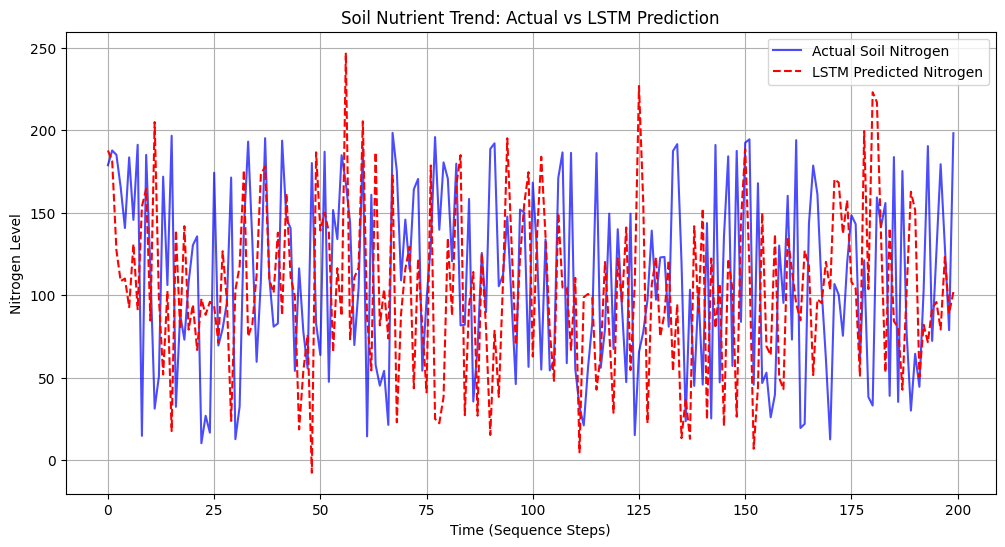

This plot demonstrates how the LSTM predicts soil nutrient degradation based on climate patterns.


In [8]:

import matplotlib.pyplot as plt

# 1. Generate predictions for the test set
model.eval()
with torch.no_grad():
    test_predictions = model(X_train[1000:1200]).numpy() # Test on a new window
    actual_values = y_train[1000:1200].numpy()

# 2. Rescale back to original values
pred_rescaled = scaler_y.inverse_transform(test_predictions)
actual_rescaled = scaler_y.inverse_transform(actual_values)

# 3. Plotting the results
plt.figure(figsize=(12,6))
plt.plot(actual_rescaled, label='Actual Soil Nitrogen', color='blue', alpha=0.7)
plt.plot(pred_rescaled, label='LSTM Predicted Nitrogen', color='red', linestyle='--')
plt.title('Soil Nutrient Trend: Actual vs LSTM Prediction')
plt.xlabel('Time (Sequence Steps)')
plt.ylabel('Nitrogen Level')
plt.legend()
plt.grid(True)
plt.show()

print("This plot demonstrates how the LSTM predicts soil nutrient degradation based on climate patterns.")
